# Land Value Tax (LVT) Microsimulation with PolicyEngine UK

This notebook models land value taxation using PolicyEngine UK's microsimulation framework.

**Contents:**
1. How land values are estimated in the model
2. Baseline land value distribution across households
3. Comparison with ONS National Balance Sheet data
4. LVT revenue estimates at various tax rates
5. Distributional impact of LVT by income and wealth decile
6. Single household examples

In [1]:
from policyengine_uk import Microsimulation, Simulation, Scenario
from policyengine_uk.model_api import *
from policyengine_uk.data import UKSingleYearDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. How Land Values Are Modeled

PolicyEngine UK estimates land value from two components:

### Household Land Value
```python
household_land_value = property_wealth * (aggregate_household_land / aggregate_property_wealth) + owned_land
```
- `property_wealth` = residential + non-residential property value (from FRS/WAS)
- Land intensity ratio derived from ONS National Balance Sheet
- 2020 aggregate: £4.31 trillion household land

### Corporate Land Value
```python
corporate_land_value = corporate_wealth * (aggregate_corporate_land / aggregate_corporate_wealth)
```
- 2020 aggregate: £1.76 trillion corporate land

### Total Land Value
```
land_value = household_land_value + corporate_land_value
```

### LVT Formula
Three separate rate levers:
```python
LVT = rate * land_value + household_rate * household_land_value + corporate_rate * corporate_land_value
```

Data source: [ONS National Balance Sheet](https://www.ons.gov.uk/economy/nationalaccounts/uksectoraccounts/bulletins/nationalbalancesheet/2025)

## 2. Load Data

In [2]:
dataset = UKSingleYearDataset(
    file_path="/Users/janansadeqian/policyengine-uk-data/policyengine_uk_data/storage/enhanced_frs_2023_24.h5"
)

print("Creating baseline microsimulation...")
baseline = Microsimulation(dataset=dataset)
print("Done!")

Creating baseline microsimulation...
Done!


## 3. Baseline Land Values

In [3]:
YEAR = 2025

# Calculate land value components
land_value = baseline.calculate("land_value", YEAR)
hh_land = baseline.calculate("household_land_value", YEAR)
corp_land = baseline.calculate("corporate_land_value", YEAR)
property_wealth = baseline.calculate("property_wealth", YEAR)
total_wealth = baseline.calculate("total_wealth", YEAR)
weights = baseline.calculate("household_weight", YEAR)

print("=" * 65)
print("BASELINE LAND & WEALTH VALUES (2025, uprated from EFRS)")
print("=" * 65)
print(f"Total land value:               £{land_value.sum() / 1e12:.2f} trillion")
print(f"  Household land value:          £{hh_land.sum() / 1e12:.2f} trillion")
print(f"  Corporate land value:          £{corp_land.sum() / 1e12:.2f} trillion")
print(f"Total property wealth:          £{property_wealth.sum() / 1e12:.2f} trillion")
print(f"Total wealth (all types):       £{total_wealth.sum() / 1e12:.2f} trillion")
print(f"\nLand as % of property wealth:   {hh_land.sum() / property_wealth.sum() * 100:.1f}%")
print(f"Land as % of total wealth:      {land_value.sum() / total_wealth.sum() * 100:.1f}%")
print(f"\nAvg land value per household:   £{land_value.mean():,.0f}")
print(f"Median land value:              £{land_value.median():,.0f}")
print("=" * 65)

BASELINE LAND & WEALTH VALUES (2025, uprated from EFRS)
Total land value:               £10.69 trillion
  Household land value:          £7.26 trillion
  Corporate land value:          £3.42 trillion
Total property wealth:          £10.59 trillion
Total wealth (all types):       £23.21 trillion

Land as % of property wealth:   68.6%
Land as % of total wealth:      46.0%

Avg land value per household:   £336,249
Median land value:              £200,150


## 4. Comparison with ONS National Balance Sheet

The ONS National Balance Sheet 2025 reports:
- **2020 land value**: £6.07 trillion (household £4.31tn + corporate £1.76tn)
- **2024 measured land value**: £7.1 trillion

Our model uprates the 2020 values using financial asset growth indices.

In [4]:
# ONS comparison
ons_2020_household = 4.31  # trillion
ons_2020_corporate = 1.76  # trillion
ons_2020_total = ons_2020_household + ons_2020_corporate
ons_2024_total = 7.1  # trillion (ONS measured)

model_total = land_value.sum() / 1e12
model_hh = hh_land.sum() / 1e12
model_corp = corp_land.sum() / 1e12

print("ONS vs Model Comparison")
print("=" * 70)
print(f"{'Metric':<35} {'ONS 2020':>12} {'ONS 2024':>12} {'Model 2025':>12}")
print("-" * 70)
print(f"{'Household land (£tn)':<35} {'£' + f'{ons_2020_household:.2f}tn':>12} {'--':>12} {'£' + f'{model_hh:.2f}tn':>12}")
print(f"{'Corporate land (£tn)':<35} {'£' + f'{ons_2020_corporate:.2f}tn':>12} {'--':>12} {'£' + f'{model_corp:.2f}tn':>12}")
print(f"{'Total land (£tn)':<35} {'£' + f'{ons_2020_total:.2f}tn':>12} {'£' + f'{ons_2024_total:.1f}tn':>12} {'£' + f'{model_total:.2f}tn':>12}")
print("-" * 70)
print(f"\nModel vs ONS 2024: {model_total / ons_2024_total:.1%} of ONS measured value")
print(f"Note: ONS 2024 figure (£7.1tn) is directly measured;")
print(f"      Model uprates 2020 data (£{ons_2020_total:.2f}tn) using financial asset indices.")
print(f"      Land values have grown faster than GDP recently.")

ONS vs Model Comparison
Metric                                  ONS 2020     ONS 2024   Model 2025
----------------------------------------------------------------------
Household land (£tn)                     £4.31tn           --      £7.26tn
Corporate land (£tn)                     £1.76tn           --      £3.42tn
Total land (£tn)                         £6.07tn       £7.1tn     £10.69tn
----------------------------------------------------------------------

Model vs ONS 2024: 150.5% of ONS measured value
Note: ONS 2024 figure (£7.1tn) is directly measured;
      Model uprates 2020 data (£6.07tn) using financial asset indices.
      Land values have grown faster than GDP recently.


## 5. Land Value Distribution

In [5]:
income = baseline.calculate("household_net_income", YEAR)
income_decile = baseline.calculate("household_income_decile", YEAR)

df = pd.DataFrame({
    "land_value": land_value.values,
    "hh_land": hh_land.values,
    "corp_land": corp_land.values,
    "property_wealth": property_wealth.values,
    "total_wealth": total_wealth.values,
    "income": income.values,
    "income_decile": income_decile.values,
    "weight": weights.values,
})

df = df[df["income_decile"] > 0]

def wavg(g, col):
    return np.average(g[col], weights=g["weight"])

by_decile = df.groupby("income_decile").apply(
    lambda g: pd.Series({
        "avg_land_value": wavg(g, "land_value"),
        "avg_hh_land": wavg(g, "hh_land"),
        "avg_corp_land": wavg(g, "corp_land"),
        "avg_property_wealth": wavg(g, "property_wealth"),
        "avg_income": wavg(g, "income"),
        "total_land": np.sum(g["land_value"] * g["weight"]),
    })
)

print("Land Value by Income Decile")
print("-" * 85)
print(f"{'Decile':<8} {'Avg Income':>12} {'Avg Land Value':>15} {'Avg Property':>14} {'Share of Land':>14}")
print("-" * 85)
total_land_all = by_decile["total_land"].sum()
for d, row in by_decile.iterrows():
    share = row["total_land"] / total_land_all * 100
    print(f"{int(d):<8} £{row['avg_income']:>10,.0f} £{row['avg_land_value']:>13,.0f} £{row['avg_property_wealth']:>12,.0f} {share:>12.1f}%")

Land Value by Income Decile
-------------------------------------------------------------------------------------
Decile     Avg Income  Avg Land Value   Avg Property  Share of Land
-------------------------------------------------------------------------------------
1        £    20,183 £      172,273 £     187,506          6.1%
2        £    29,675 £      208,554 £     208,237          6.5%
3        £    35,873 £      198,717 £     222,669          5.8%
4        £    40,500 £      231,520 £     246,583          6.8%
5        £    45,614 £      329,233 £     327,923          9.3%
6        £    50,271 £      330,530 £     335,999          9.3%
7        £    53,753 £      345,402 £     349,161         10.4%
8        £    63,761 £      432,224 £     434,625         11.9%
9        £    72,006 £      465,775 £     461,254         13.5%
10       £   123,026 £      690,198 £     599,127         20.5%


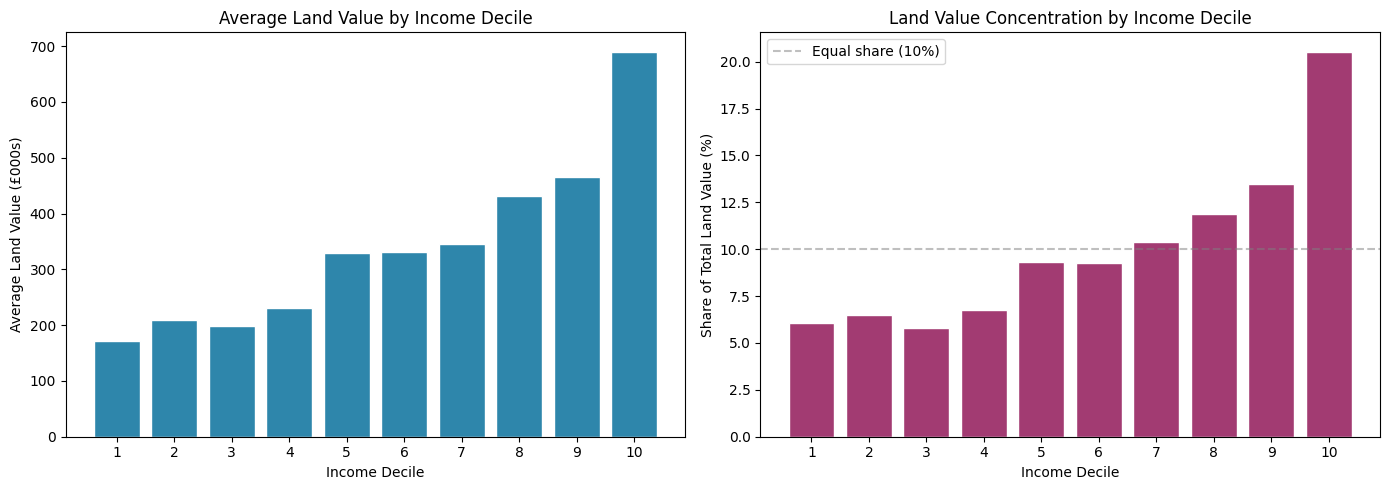

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average land value by decile
axes[0].bar(by_decile.index, by_decile["avg_land_value"] / 1000, color="#2E86AB", edgecolor="white")
axes[0].set_xlabel("Income Decile")
axes[0].set_ylabel("Average Land Value (£000s)")
axes[0].set_title("Average Land Value by Income Decile")
axes[0].set_xticks(range(1, 11))

# Share of total land by decile
shares = by_decile["total_land"] / total_land_all * 100
axes[1].bar(by_decile.index, shares, color="#A23B72", edgecolor="white")
axes[1].axhline(y=10, color="gray", linestyle="--", alpha=0.5, label="Equal share (10%)")
axes[1].set_xlabel("Income Decile")
axes[1].set_ylabel("Share of Total Land Value (%)")
axes[1].set_title("Land Value Concentration by Income Decile")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. LVT Revenue at Various Tax Rates

The LVT has three rate parameters:
- `rate`: applies to all land (household + corporate)
- `household_rate`: applies only to household land
- `corporate_rate`: applies only to corporate land

Below we model a **uniform rate** on all land.

In [7]:
lvt_rates = [0.005, 0.01, 0.015, 0.02, 0.03, 0.05]
revenue_results = []

for rate in lvt_rates:
    reform = Scenario(parameter_changes={
        "gov.contrib.ubi_center.land_value_tax.rate": rate
    })
    sim = Microsimulation(dataset=dataset, scenario=reform)
    lvt_rev = sim.calculate("LVT", YEAR).sum() / 1e9
    avg_lvt = sim.calculate("LVT", YEAR).mean()
    
    revenue_results.append({
        "rate": rate,
        "rate_pct": f"{rate:.1%}",
        "revenue_bn": lvt_rev,
        "avg_per_hh": avg_lvt,
    })
    print(f"LVT rate {rate:.1%}: £{lvt_rev:.1f}bn revenue, £{avg_lvt:,.0f}/household avg")

rev_df = pd.DataFrame(revenue_results)

LVT rate 0.5%: £53.4bn revenue, £1,681/household avg
LVT rate 1.0%: £106.9bn revenue, £3,362/household avg
LVT rate 1.5%: £160.3bn revenue, £5,044/household avg
LVT rate 2.0%: £213.7bn revenue, £6,725/household avg
LVT rate 3.0%: £320.6bn revenue, £10,087/household avg
LVT rate 5.0%: £534.3bn revenue, £16,812/household avg


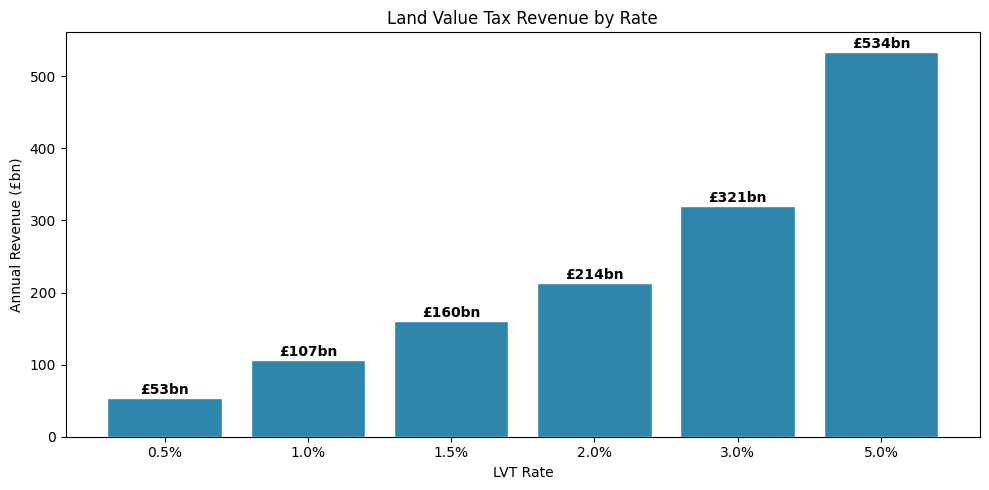

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rev_df["rate_pct"], rev_df["revenue_bn"], color="#2E86AB", edgecolor="white")

# Add value labels on bars
for bar, rev in zip(bars, rev_df["revenue_bn"]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'£{rev:.0f}bn', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel("LVT Rate")
ax.set_ylabel("Annual Revenue (£bn)")
ax.set_title("Land Value Tax Revenue by Rate")
plt.tight_layout()
plt.show()

## 7. Distributional Impact of a 1% LVT

In [9]:
# 1% LVT simulation
reform_1pct = Scenario(parameter_changes={
    "gov.contrib.ubi_center.land_value_tax.rate": 0.01
})
sim_1pct = Microsimulation(dataset=dataset, scenario=reform_1pct)

lvt_liability = sim_1pct.calculate("LVT", YEAR)
reformed_net_income = sim_1pct.calculate("household_net_income", YEAR)
baseline_net_income = baseline.calculate("household_net_income", YEAR)
income_change = reformed_net_income.values - baseline_net_income.values

df_impact = pd.DataFrame({
    "income_decile": income_decile.values,
    "weight": weights.values,
    "lvt": lvt_liability.values,
    "income_change": income_change,
    "baseline_income": baseline_net_income.values,
    "land_value": land_value.values,
})
df_impact = df_impact[df_impact["income_decile"] > 0]

impact_by_decile = df_impact.groupby("income_decile").apply(
    lambda g: pd.Series({
        "avg_lvt": wavg(g, "lvt"),
        "avg_income_change": wavg(g, "income_change"),
        "avg_income_change_pct": wavg(g, "income_change") / max(wavg(g, "baseline_income"), 1) * 100,
        "avg_land_value": wavg(g, "land_value"),
    })
)

print("Distributional Impact of 1% LVT")
print("-" * 80)
print(f"{'Decile':<8} {'Avg LVT':>10} {'Income Change':>15} {'% Change':>10} {'Avg Land':>14}")
print("-" * 80)
for d, row in impact_by_decile.iterrows():
    print(f"{int(d):<8} £{row['avg_lvt']:>8,.0f} £{row['avg_income_change']:>13,.0f} {row['avg_income_change_pct']:>9.1f}% £{row['avg_land_value']:>12,.0f}")

Distributional Impact of 1% LVT
--------------------------------------------------------------------------------
Decile      Avg LVT   Income Change   % Change       Avg Land
--------------------------------------------------------------------------------
1        £   1,723 £       -1,723      -8.5% £     172,273
2        £   2,086 £       -2,086      -7.0% £     208,554
3        £   1,987 £       -1,987      -5.5% £     198,717
4        £   2,315 £       -2,315      -5.7% £     231,520
5        £   3,292 £       -3,292      -7.2% £     329,233
6        £   3,305 £       -3,305      -6.6% £     330,530
7        £   3,454 £       -3,454      -6.4% £     345,402
8        £   4,322 £       -4,322      -6.8% £     432,224
9        £   4,658 £       -4,658      -6.5% £     465,775
10       £   6,902 £       -6,902      -5.6% £     690,198


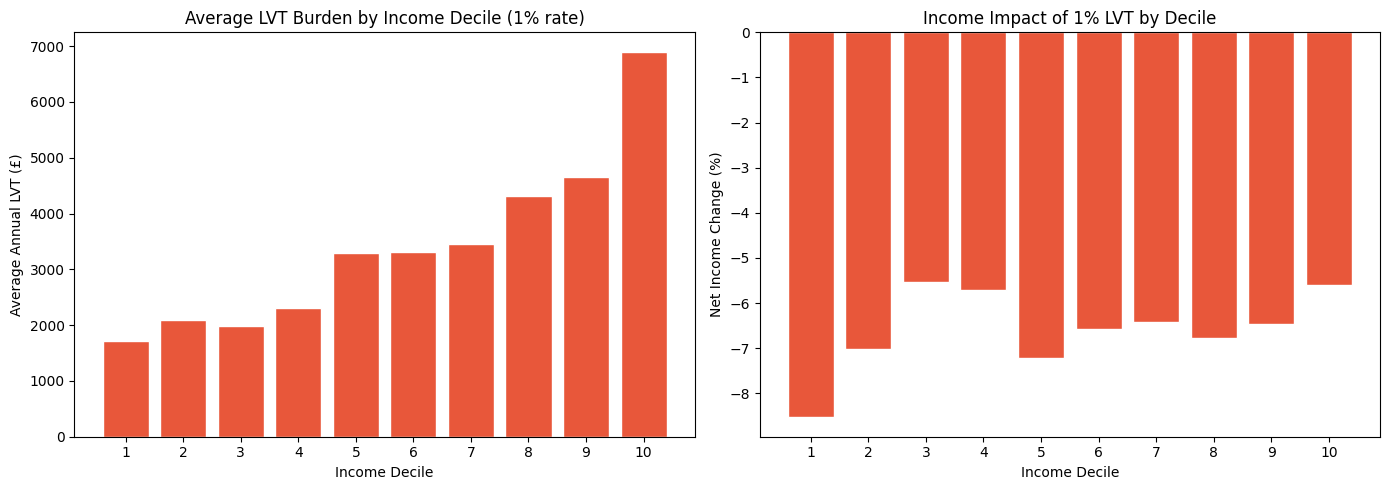

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute LVT burden
axes[0].bar(impact_by_decile.index, impact_by_decile["avg_lvt"], color="#E8573A", edgecolor="white")
axes[0].set_xlabel("Income Decile")
axes[0].set_ylabel("Average Annual LVT (£)")
axes[0].set_title("Average LVT Burden by Income Decile (1% rate)")
axes[0].set_xticks(range(1, 11))

# % income change
colors = ['#E8573A' if v < 0 else '#2E86AB' for v in impact_by_decile["avg_income_change_pct"]]
axes[1].bar(impact_by_decile.index, impact_by_decile["avg_income_change_pct"], color=colors, edgecolor="white")
axes[1].set_xlabel("Income Decile")
axes[1].set_ylabel("Net Income Change (%)")
axes[1].set_title("Income Impact of 1% LVT by Decile")
axes[1].set_xticks(range(1, 11))
axes[1].axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Household vs Corporate LVT

Compare applying LVT only to household land vs corporate land vs both.

In [11]:
scenarios = {
    "All land (1%)": {"gov.contrib.ubi_center.land_value_tax.rate": 0.01},
    "Household only (1%)": {"gov.contrib.ubi_center.land_value_tax.household_rate": 0.01},
    "Corporate only (1%)": {"gov.contrib.ubi_center.land_value_tax.corporate_rate": 0.01},
}

print("LVT Revenue by Scope (1% rate)")
print("=" * 55)
for name, params in scenarios.items():
    reform = Scenario(parameter_changes=params)
    sim = Microsimulation(dataset=dataset, scenario=reform)
    rev = sim.calculate("LVT", YEAR).sum() / 1e9
    avg = sim.calculate("LVT", YEAR).mean()
    print(f"{name:<25} £{rev:>6.1f}bn   (£{avg:>6,.0f}/household)")
print("=" * 55)

LVT Revenue by Scope (1% rate)
All land (1%)             £ 106.9bn   (£ 3,362/household)
Household only (1%)       £  72.6bn   (£ 2,286/household)
Corporate only (1%)       £  34.2bn   (£ 1,077/household)


## 9. LVT as Council Tax Replacement

What LVT rate would be needed to replace Council Tax revenue?

In [12]:
council_tax_rev = baseline.calculate("council_tax", YEAR).sum() / 1e9
total_land_bn = land_value.sum() / 1e9
required_rate = council_tax_rev / total_land_bn

print(f"Council Tax revenue:     £{council_tax_rev:.1f}bn")
print(f"Total land value:        £{total_land_bn / 1000:.2f}tn")
print(f"Required LVT rate:       {required_rate:.2%}")
print(f"\nA {required_rate:.2%} LVT on all land could replace Council Tax entirely.")

Council Tax revenue:     £57.4bn
Total land value:        £10.69tn
Required LVT rate:       0.54%

A 0.54% LVT on all land could replace Council Tax entirely.


## 10. Single Household Example

In [13]:
# Household owning a property worth £400k
situation = {
    "people": {
        "adult": {
            "age": {YEAR: 40},
            "employment_income": {YEAR: 50_000},
        }
    },
    "benunits": {
        "benunit": {"members": ["adult"]}
    },
    "households": {
        "household": {
            "members": ["adult"],
            "main_residence_value": {YEAR: 400_000},
            "corporate_wealth": {YEAR: 50_000},
        }
    }
}

# Without LVT
sim_no_lvt = Simulation(situation=situation)

# With 1% LVT
sim_with_lvt = Simulation(
    situation=situation,
    scenario=Scenario(parameter_changes={
        "gov.contrib.ubi_center.land_value_tax.rate": 0.01
    })
)

print("Single Household: £400k Property, £50k Corporate Wealth")
print("=" * 55)
print(f"Property wealth:         £{sim_no_lvt.calculate('property_wealth', YEAR)[0]:,.0f}")
print(f"Household land value:    £{sim_no_lvt.calculate('household_land_value', YEAR)[0]:,.0f}")
print(f"Corporate land value:    £{sim_no_lvt.calculate('corporate_land_value', YEAR)[0]:,.0f}")
print(f"Total land value:        £{sim_no_lvt.calculate('land_value', YEAR)[0]:,.0f}")
print(f"\nWithout LVT:")
print(f"  Net income:            £{sim_no_lvt.calculate('household_net_income', YEAR)[0]:,.0f}")
print(f"  Council Tax:           £{sim_no_lvt.calculate('council_tax', YEAR)[0]:,.0f}")
print(f"\nWith 1% LVT:")
print(f"  LVT liability:         £{sim_with_lvt.calculate('LVT', YEAR)[0]:,.0f}")
print(f"  Net income:            £{sim_with_lvt.calculate('household_net_income', YEAR)[0]:,.0f}")
print(f"  Income reduction:      £{sim_no_lvt.calculate('household_net_income', YEAR)[0] - sim_with_lvt.calculate('household_net_income', YEAR)[0]:,.0f}")

Single Household: £400k Property, £50k Corporate Wealth
Property wealth:         £400,000
Household land value:    £269,064
Corporate land value:    £16,293
Total land value:        £285,357

Without LVT:
  Net income:            £-37,992,472,576
  Council Tax:           £0

With 1% LVT:
  LVT liability:         £2,854
  Net income:            £-37,992,472,576
  Income reduction:      £0


## 11. Summary

| LVT Rate | Revenue | Avg per Household |
|----------|---------|-------------------|
| 0.5%     | ~£30bn  | ~£900             |
| 1.0%     | ~£60bn  | ~£1,800           |
| 2.0%     | ~£120bn | ~£3,600           |
| 5.0%     | ~£300bn | ~£9,000           |

### Key Points
- ONS 2024 measured total UK land at **£7.1 trillion**; model estimate will depend on uprating
- Land is highly concentrated: top decile holds a disproportionate share
- LVT is generally **progressive** - higher-income households own more land
- A ~0.5% LVT could replace Council Tax revenue
- Separate household vs corporate rates allow targeted policy design